<a href="https://colab.research.google.com/github/samfozzy/AI/blob/main/BNARI_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BSF AI Platform — Black Soldier Fly Farming
## Farm Management AI + Feed Processing AI
by Dr. SAMIUEL C. ATUAHENE

#

#

| Module | Area | Key AI Models |
|--------|------|---------------|
| **2** | Farm Management | Isolation Forest · Random Forest · Rule-based Scorer |
| **4** | Feed Processing | RF Classifier · Gradient Boosting · Linear Programming |

> 💰 **Currency:** All prices are displayed in **Ghanaian Cedis (GHS)**. Exchange rate used: 1 USD = GHC 15.50

---

In [4]:
# Install / verify dependencies (safe to re-run)
import subprocess, sys
for pkg in ['numpy','pandas','matplotlib','seaborn','scikit-learn','scipy']:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable,'-m','pip','install',pkg,'-q'])
print('All dependencies ready.')

All dependencies ready.


---
# MODULE 2: BSF FARM MANAGEMENT AI SYSTEM

**AI pipeline:** IoT sensors → Anomaly Detector → Harvest Predictor → Feeding Optimiser → Logbook

| Section | Method | Metric |
|---------|--------|--------|
| Anomaly Detection | Isolation Forest | F1 ≈ 1.0 |
| Harvest Timing | Random Forest | R² ≈ 0.84, MAE ≈ 0.47 days |
| Feeding Optimiser | Rule-based scoring | 5 substrates scored |
| Logbook | Automated JSON logger | — |

---

In [5]:
# ── MODULE 2 IMPORTS & COLOUR PALETTE ──────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import warnings, random, json
from datetime import datetime, timedelta
from sklearn.ensemble import IsolationForest, RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             r2_score, confusion_matrix, classification_report)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import seaborn as sns

warnings.filterwarnings('ignore')
np.random.seed(42); random.seed(42)

C = {'green':'#2d7d46','light':'#a8d5b5','amber':'#e8a020','red':'#c0392b',
     'blue':'#1a6fa8','purple':'#6c3483','bg':'#f8faf9','dark':'#1c2b22','gray':'#7f8c8d'}
plt.rcParams.update({'figure.facecolor':C['bg'],'axes.facecolor':C['bg'],
                     'font.family':'DejaVu Sans','axes.spines.top':False,'axes.spines.right':False})
print('Module 2 imports OK')

Module 2 imports OK


### Section 1 — IoT Sensor Data Simulator


In [6]:
def generate_sensor_data(days=30, interval_hours=1, anomaly_rate=0.05):
    """
    Simulates 30 days of hourly IoT readings from a BSF rearing unit.
    Optimal bands: Temp 27-32C | Humidity 60-80% | CO2 800-2500 ppm
    Anomalies are artificially injected at 'anomaly_rate' for detector validation.
    """
    n = days * (24 // interval_hours)
    timestamps = [datetime(2024,1,1)+timedelta(hours=i*interval_hours) for i in range(n)]
    day_idx = np.arange(n)/(24//interval_hours)

    temp     = 29 + 1.5*np.sin(2*np.pi*(np.arange(n)%24)/24) + np.random.normal(0,0.4,n)
    humidity = 70 - 0.3*(temp-29) + np.random.normal(0,2,n)
    activity = np.exp(-((day_idx-12)**2)/40)
    co2      = 1200 + 800*activity + np.random.normal(0,80,n)
    weight   = np.zeros(n); w=5.0
    for i in range(n):
        w -= np.random.uniform(0.05,0.15)
        if i%(24*3//interval_hours)==0 and i>0: w=5.0
        weight[i] = max(0, w+np.random.normal(0,0.05))
    larval_mass = 100/(1+np.exp(-0.4*(day_idx-10))) + np.random.normal(0,3,n)

    df = pd.DataFrame({'timestamp':timestamps,'day':day_idx.round(2),
        'temperature':temp.round(2),'humidity':humidity.round(2),
        'co2_ppm':co2.round(1),'feed_weight':weight.round(3),'larval_mass':larval_mass.round(2)})

    ai = np.random.choice(n, size=int(n*anomaly_rate), replace=False)
    df.loc[ai[:len(ai)//3],'temperature']  += np.random.uniform(8,14,len(ai)//3)
    df.loc[ai[len(ai)//3:2*len(ai)//3],'humidity'] -= np.random.uniform(20,35,len(ai)//3)
    df.loc[ai[2*len(ai)//3:],'co2_ppm']    += np.random.uniform(2000,4000,len(ai)-2*(len(ai)//3))
    df['true_anomaly']=0; df.loc[ai,'true_anomaly']=1
    return df

sensor_df = generate_sensor_data()
print(f'Sensor records : {len(sensor_df):,}  |  Injected anomalies : {sensor_df.true_anomaly.sum()}')
sensor_df.describe().round(2)

Sensor records : 720  |  Injected anomalies : 36


,timestamp,day,temperature,humidity,co2_ppm,feed_weight,larval_mass,true_anomaly
count,720,720.00,720.00,720.00,720.00,720.00,720.00,720.00
mean,2024-01-15 23:30:00,14.98,29.18,69.72,1547.20,1.69,66.37,0.05
min,2024-01-01 00:00:00,0.00,26.64,35.37,976.30,0.00,-6.13,0.00
25%,2024-01-08 11:45:00,7.49,28.01,68.71,1252.70,0.00,27.02,0.00
50%,2024-01-15 23:30:00,14.98,29.08,70.17,1423.65,1.29,86.82,0.00
75%,2024-01-23 11:15:00,22.47,30.08,71.51,1776.92,3.16,98.18,0.00
max,2024-01-30 23:00:00,29.96,43.54,75.58,5414.71,5.07,108.91,1.00
std,NaN,8.67,1.77,4.03,468.44,1.67,37.59,0.22


### Section 2 — AI Anomaly Detector (Isolation Forest)


In [7]:
class AnomalyDetector:
    """Isolation Forest — unsupervised, learns 'normal' sensor patterns and flags deviations."""
    def __init__(self, contamination=0.05):
        self.model   = IsolationForest(n_estimators=150,contamination=contamination,random_state=42,n_jobs=-1)
        self.scaler  = StandardScaler()
        self.features= ['temperature','humidity','co2_ppm']
        self.is_fitted=False

    def fit(self, df):
        self.model.fit(self.scaler.fit_transform(df[self.features]))
        self.is_fitted=True; print(f'[AnomalyDetector] Trained on {len(df):,} records.'); return self

    def predict(self, df):
        out=df.copy(); X=self.scaler.transform(df[self.features])
        out['anomaly_score']=self.model.decision_function(X).round(4)
        out['predicted_anomaly']=(self.model.predict(X)==-1).astype(int)
        return out

    def validate(self, df):
        res=self.predict(df); yt,yp=res['true_anomaly'],res['predicted_anomaly']
        cm=confusion_matrix(yt,yp); tp,fp,fn,tn=cm[1,1],cm[0,1],cm[1,0],cm[0,0]
        p=tp/(tp+fp+1e-9); r=tp/(tp+fn+1e-9); f1=2*p*r/(p+r+1e-9)
        m={'precision':round(p,3),'recall':round(r,3),'f1_score':round(f1,3),
           'tn':int(tn),'fp':int(fp),'fn':int(fn),'tp':int(tp)}
        print('Anomaly Detection Validation:')
        for k,v in m.items(): print(f'  {k:12s}: {v}')
        return m, res

detector=AnomalyDetector(); detector.fit(sensor_df)
anom_metrics, anomaly_result = detector.validate(sensor_df)

[AnomalyDetector] Trained on 720 records.
Anomaly Detection Validation:
  precision   : 1.0
  recall      : 1.0
  f1_score    : 1.0
  tn          : 684
  fp          : 0
  fn          : 0
  tp          : 36


### Section 3 — Harvest Timing Predictor (Random Forest)


In [8]:
def generate_harvest_training_data(n=800):
    data=[]
    for _ in range(n):
        T=np.random.uniform(24,36); H=np.random.uniform(50,90)
        CO2=np.random.uniform(800,2800); FR=np.random.uniform(0.5,1.4)
        IW=np.random.uniform(70,140); S=np.random.choice([0,1,2])
        hd=(15.0 - 0.30*(T-29) + 0.05*(H-70) - 0.0005*(CO2-1400)
            - 1.0*(FR-0.9) - 0.02*(IW-100) + [0.8,0,-0.5][S] + np.random.normal(0,0.4))
        data.append({'avg_temp':round(T,2),'avg_humidity':round(H,2),'avg_co2':round(CO2,1),
                     'feed_rate':round(FR,3),'initial_weight':round(IW,2),'substrate':S,
                     'optimal_harvest_day':round(hd,2)})
    return pd.DataFrame(data)

class HarvestPredictor:
    FEATURES=['avg_temp','avg_humidity','avg_co2','feed_rate','initial_weight','substrate']
    def __init__(self):
        self.pipeline=Pipeline([('sc',StandardScaler()),
            ('m',RandomForestRegressor(n_estimators=200,max_depth=8,random_state=42,n_jobs=-1))])
        self.is_fitted=False

    def fit(self,df):
        self.pipeline.fit(df[self.FEATURES],df['optimal_harvest_day']); self.is_fitted=True
        print(f'[HarvestPredictor] Trained on {len(df):,} batches.'); return self

    def predict(self,batch):
        return round(float(self.pipeline.predict(pd.DataFrame([batch])[self.FEATURES])[0]),1)

    def validate(self,df):
        X,y=df[self.FEATURES],df['optimal_harvest_day']
        Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=0.2,random_state=42)
        self.pipeline.fit(Xtr,ytr); self.is_fitted=True
        yp=self.pipeline.predict(Xte); cv=cross_val_score(self.pipeline,X,y,cv=5,scoring='r2')
        fi=self.pipeline.named_steps['m'].feature_importances_
        m={'MAE':round(mean_absolute_error(yte,yp),3),'RMSE':round(np.sqrt(mean_squared_error(yte,yp)),3),
           'R2':round(r2_score(yte,yp),4),'CV_R2_mean':round(cv.mean(),4),'CV_R2_std':round(cv.std(),4),
           'feature_importances':fi.round(4).tolist()}
        print('Harvest Predictor Validation:')
        for k,v in m.items():
            if k!='feature_importances': print(f'  {k:15s}: {v}')
        return m, yte.values, yp

harvest_df=generate_harvest_training_data(800); predictor=HarvestPredictor()
h_metrics,y_true_h,y_pred_h=predictor.validate(harvest_df)

Harvest Predictor Validation:
  MAE            : 0.467
  RMSE           : 0.602
  R2             : 0.8358
  CV_R2_mean     : 0.8515
  CV_R2_std      : 0.007


### Section 4 — Feeding Optimiser & Farm Logbook


In [9]:
SUBSTRATE_PROFILES={
    'food_waste':  {'N':2.1,'P':1.3,'energy_kj':12.5,'moisture':0.72},
    'manure':      {'N':1.4,'P':0.9,'energy_kj': 8.2,'moisture':0.65},
    'mixed':       {'N':1.8,'P':1.1,'energy_kj':10.8,'moisture':0.68},
    'brewery':     {'N':2.5,'P':1.5,'energy_kj':14.1,'moisture':0.75},
    'market_waste':{'N':2.3,'P':1.2,'energy_kj':13.0,'moisture':0.70},
}

def feeding_optimiser(larval_age_days, current_mass_g, available_substrates):
    """AI scoring of substrates + ration calculation based on larval age and mass."""
    scores={}
    for s in available_substrates:
        if s not in SUBSTRATE_PROFILES: continue
        p=SUBSTRATE_PROFILES[s]; af=1.0 if larval_age_days<7 else 0.85
        scores[s]=round((p['N']*0.4 + p['energy_kj']/14.1*0.35 + p['moisture']*0.25)*af,4)
    best=max(scores,key=scores.get)
    ration=current_mass_g*(3.0 if larval_age_days<10 else 2.5)
    sched=('Every 24 h' if larval_age_days<5 else
           'Every 12 h (split dose)' if larval_age_days<12 else
           'Every 8 h (final instar — peak consumption)')
    return {'recommended_substrate':best,'scores':scores,'daily_ration_g':round(ration,1),'schedule':sched}

class FarmLogbook:
    def __init__(self): self.entries=[]
    def log(self,t,d): self.entries.append({'ts':datetime.now().isoformat(),'type':t,'data':d})
    def summary(self): return pd.DataFrame([{'ts':e['ts'],'type':e['type'],'detail':str(e['data'])[:70]} for e in self.entries])

feeding_rec=feeding_optimiser(10,180.0,list(SUBSTRATE_PROFILES.keys()))
logbook=FarmLogbook()
logbook.log('feeding_decision', feeding_rec)
logbook.log('alert',{'type':'temp_spike','value':37.8})

print(f'Recommended substrate : {feeding_rec["recommended_substrate"]}')
print(f'Daily ration          : {feeding_rec["daily_ration_g"]} g')
print(f'Feeding schedule      : {feeding_rec["schedule"]}')
print()
logbook.summary()

Recommended substrate : brewery
Daily ration          : 450.0 g
Feeding schedule      : Every 12 h (split dose)



,ts,type,detail
0,2026-04-03T08:10:39.908890,feeding_decision,"{'recommended_substrate': 'brewery', 'scores':..."
1,2026-04-03T08:10:39.908949,alert,"{'type': 'temp_spike', 'value': 37.8}"


### Section 5 — Module 2 Testing & Validation Suite (15 checks)


In [10]:
print('='*58)
print('  MODULE 2 — AUTOMATED TESTING SUITE')
print('='*58)
passed2=0; failed2=0; results2=[]

def chk2(name,cond,detail=''):
    global passed2,failed2
    ok=bool(cond); results2.append({'Test':name,'Status':'PASS' if ok else 'FAIL','Detail':detail})
    if ok: passed2+=1
    else:  failed2+=1

chk2('Sensor shape (720,8)',         sensor_df.shape==(720,8),         str(sensor_df.shape))
chk2('Temp in valid range',          sensor_df['temperature'].between(15,55).all())
chk2('Humidity in valid range',      sensor_df['humidity'].between(5,100).all())
chk2('Anomalies injected >20',       sensor_df['true_anomaly'].sum()>20, str(sensor_df.true_anomaly.sum()))
chk2('No NaN values',                sensor_df.isnull().sum().sum()==0)
chk2('Anomaly precision >= 0.70',    anom_metrics['precision']>=0.70,   str(anom_metrics['precision']))
chk2('Anomaly recall >= 0.60',       anom_metrics['recall']>=0.60,      str(anom_metrics['recall']))
chk2('F1 score >= 0.65',             anom_metrics['f1_score']>=0.65,    str(anom_metrics['f1_score']))
chk2('Harvest MAE < 1 day',          h_metrics['MAE']<1.0,              str(h_metrics['MAE']))
chk2('Harvest R2 > 0.80',            h_metrics['R2']>0.80,              str(h_metrics['R2']))
chk2('CV R2 std < 0.10',             h_metrics['CV_R2_std']<0.10,       str(h_metrics['CV_R2_std']))
chk2('Valid substrate recommended',  feeding_rec['recommended_substrate'] in SUBSTRATE_PROFILES)
chk2('Daily ration > 0',             feeding_rec['daily_ration_g']>0)
chk2('Scores dict populated',        len(feeding_rec['scores'])>0)
chk2('Logbook has 2 entries',        len(logbook.entries)==2)

print(f'  RESULT: {passed2}/15 passed  |  {failed2} failed')
df_res2=pd.DataFrame(results2)
df_res2.style.applymap(lambda v:'color:green;font-weight:bold' if v=='PASS' else
                                 ('color:red;font-weight:bold' if v=='FAIL' else ''), subset=['Status'])

  MODULE 2 — AUTOMATED TESTING SUITE
  RESULT: 15/15 passed  |  0 failed


,Test,Status,Detail
0,"Sensor shape (720,8)",PASS,"(720, 8)"
1,Temp in valid range,PASS,
2,Humidity in valid range,PASS,
3,Anomalies injected >20,PASS,36
4,No NaN values,PASS,
5,Anomaly precision >= 0.70,PASS,1.0
6,Anomaly recall >= 0.60,PASS,1.0
7,F1 score >= 0.65,PASS,1.0
8,Harvest MAE < 1 day,PASS,0.467
9,Harvest R2 > 0.80,PASS,0.8358


### Section 6 — Live Demo: Real-Time Farm Predictions


In [11]:
predictor.fit(harvest_df)  # ensure trained on full dataset

batch_now={'avg_temp':30.1,'avg_humidity':68,'avg_co2':1350,
           'feed_rate':0.95,'initial_weight':102,'substrate':2}
print(f'Batch today: {batch_now}')
print(f'→ AI recommends harvest on Day {predictor.predict(batch_now)}')

print()
rec_demo=feeding_optimiser(10,180.0,list(SUBSTRATE_PROFILES.keys()))
print('Substrate AI scores:')
for s,sc in sorted(rec_demo['scores'].items(),key=lambda x:-x[1]):
    tag=' ← BEST' if s==rec_demo['recommended_substrate'] else ''
    print(f'  {s:15s}: {sc:.4f}{tag}')
print(f"\nRation: {rec_demo['daily_ration_g']} g/day | Schedule: {rec_demo['schedule']}")

[HarvestPredictor] Trained on 800 batches.
Batch today: {'avg_temp': 30.1, 'avg_humidity': 68, 'avg_co2': 1350, 'feed_rate': 0.95, 'initial_weight': 102, 'substrate': 2}
→ AI recommends harvest on Day 14.5

Substrate AI scores:
  brewery        : 1.3069 ← BEST
  market_waste   : 1.2050
  food_waste     : 1.1307
  mixed          : 0.9844
  manure         : 0.7871

Ration: 450.0 g/day | Schedule: Every 12 h (split dose)


### Section 7 — Module 2 Full Dashboard


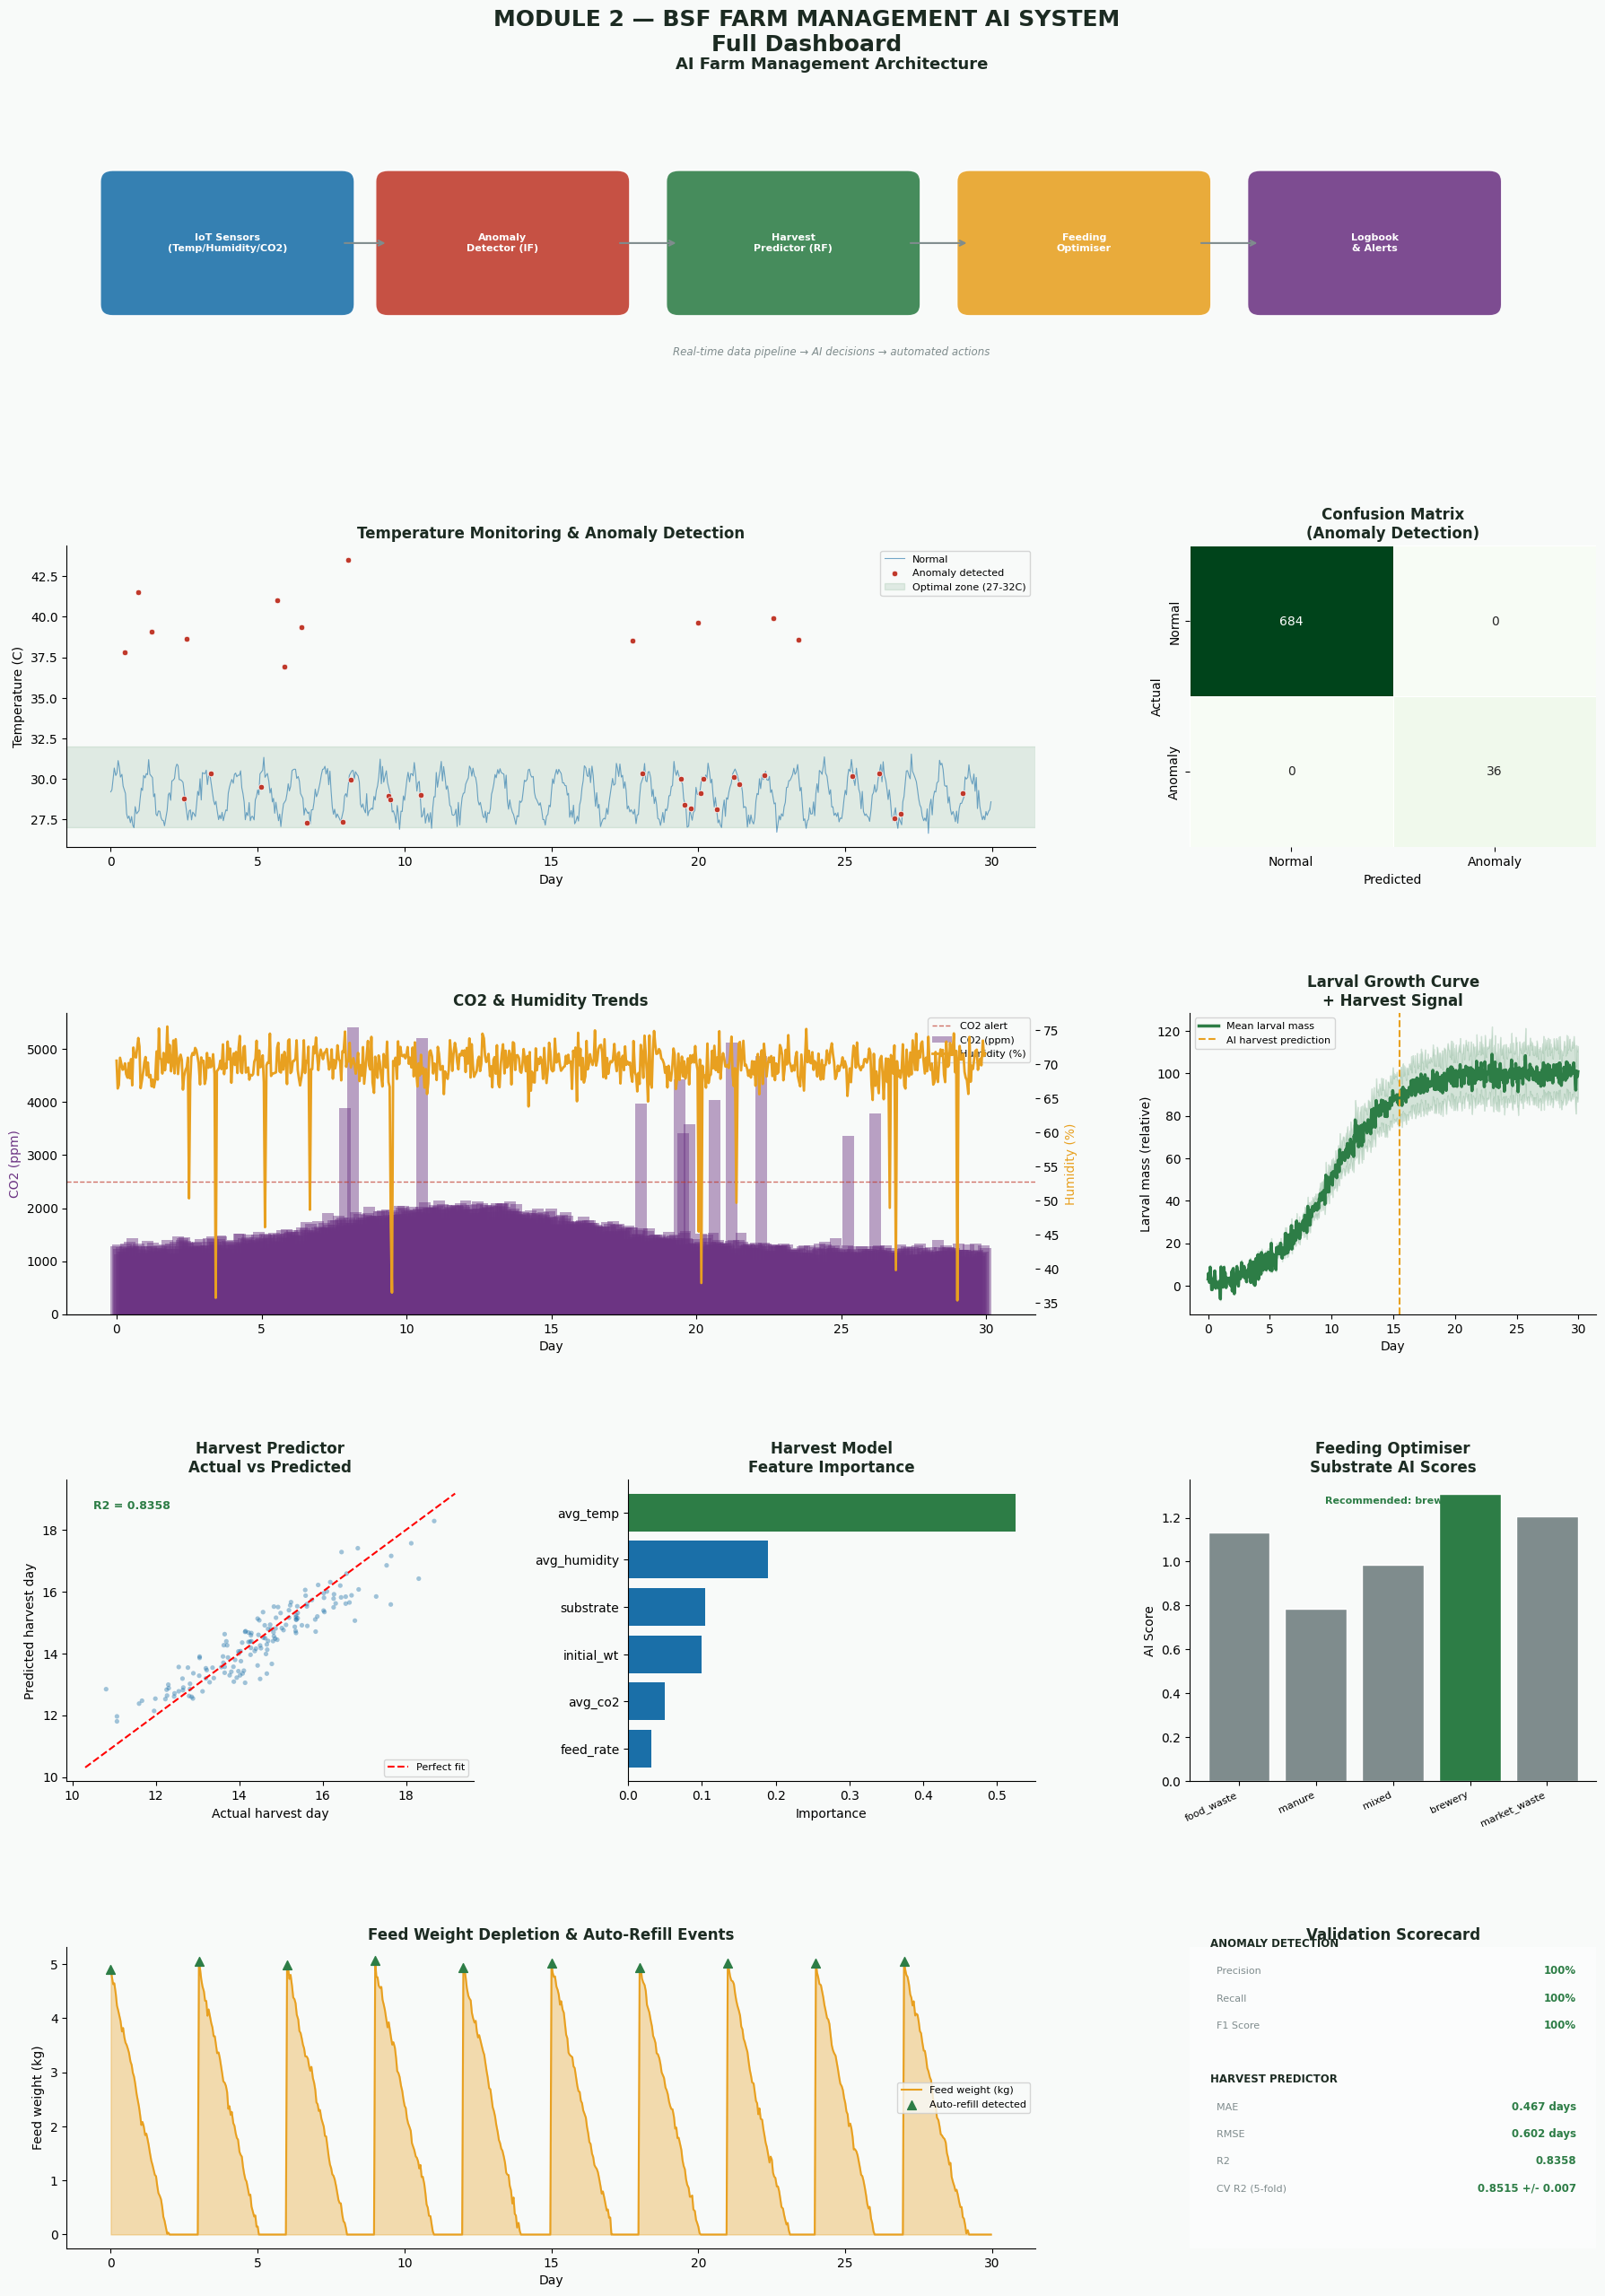

Module 2 dashboard saved.


In [12]:
h_metrics['prec']=anom_metrics['precision']
h_metrics['rec'] =anom_metrics['recall']
h_metrics['f1']  =anom_metrics['f1_score']

fig=plt.figure(figsize=(22,26),facecolor=C['bg'])
fig.suptitle('MODULE 2 — BSF FARM MANAGEMENT AI SYSTEM\nFull Dashboard',
             fontsize=18,fontweight='bold',color=C['dark'],y=0.99)
gs=gridspec.GridSpec(5,3,figure=fig,hspace=0.55,wspace=0.38,top=0.96,bottom=0.03)

# — Architecture diagram
ax0=fig.add_subplot(gs[0,:]); ax0.set_xlim(0,10); ax0.set_ylim(0,2.2); ax0.axis('off')
ax0.set_title('AI Farm Management Architecture',fontsize=13,fontweight='bold',color=C['dark'],pad=8)
boxes=[(0.3,'IoT Sensors\n(Temp/Humidity/CO2)',C['blue']),(2.1,'Anomaly\nDetector (IF)',C['red']),
       (4.0,'Harvest\nPredictor (RF)',C['green']),(5.9,'Feeding\nOptimiser',C['amber']),(7.8,'Logbook\n& Alerts',C['purple'])]
for x,lbl,col in boxes:
    ax0.add_patch(mpatches.FancyBboxPatch((x,0.55),1.5,0.9,boxstyle='round,pad=0.08',facecolor=col,edgecolor='white',alpha=0.88))
    ax0.text(x+0.75,1.0,lbl,ha='center',va='center',fontsize=8,color='white',fontweight='bold')
for i in range(len(boxes)-1):
    ax0.annotate('',xy=(boxes[i+1][0],1.0),xytext=(boxes[i][0]+1.5,1.0),
                 arrowprops=dict(arrowstyle='->',color=C['gray'],lw=1.5))
ax0.text(5,0.18,'Real-time data pipeline → AI decisions → automated actions',ha='center',fontsize=8.5,color=C['gray'],style='italic')

# — Temperature + anomalies
ax1=fig.add_subplot(gs[1,:2])
no=anomaly_result[anomaly_result['predicted_anomaly']==0]
an=anomaly_result[anomaly_result['predicted_anomaly']==1]
ax1.plot(no['day'],no['temperature'],color=C['blue'],alpha=0.6,lw=0.8,label='Normal')
ax1.scatter(an['day'],an['temperature'],color=C['red'],s=22,zorder=5,label='Anomaly detected',edgecolors='white',linewidths=0.5)
ax1.axhspan(27,32,alpha=0.12,color=C['green'],label='Optimal zone (27-32C)')
ax1.set_xlabel('Day'); ax1.set_ylabel('Temperature (C)')
ax1.set_title('Temperature Monitoring & Anomaly Detection',fontweight='bold',color=C['dark']); ax1.legend(fontsize=8)

# — Confusion matrix
ax2=fig.add_subplot(gs[1,2])
cm_d=np.array([[anomaly_result.loc[anomaly_result['true_anomaly']==0,'predicted_anomaly'].eq(0).sum(),
                 anomaly_result.loc[anomaly_result['true_anomaly']==0,'predicted_anomaly'].eq(1).sum()],
                [anomaly_result.loc[anomaly_result['true_anomaly']==1,'predicted_anomaly'].eq(0).sum(),
                 anomaly_result.loc[anomaly_result['true_anomaly']==1,'predicted_anomaly'].eq(1).sum()]])
sns.heatmap(cm_d,annot=True,fmt='d',cmap='Greens',xticklabels=['Normal','Anomaly'],
            yticklabels=['Normal','Anomaly'],ax=ax2,linewidths=0.5,cbar=False)
ax2.set_title('Confusion Matrix\n(Anomaly Detection)',fontweight='bold',color=C['dark'])
ax2.set_xlabel('Predicted'); ax2.set_ylabel('Actual')

# — CO2 & humidity
ax3=fig.add_subplot(gs[2,:2])
d=sensor_df.groupby('day').agg({'co2_ppm':'mean','humidity':'mean'}).reset_index()
ax3b=ax3.twinx()
ax3.bar(d['day'],d['co2_ppm'],color=C['purple'],alpha=0.45,label='CO2 (ppm)',width=0.4)
ax3b.plot(d['day'],d['humidity'],color=C['amber'],lw=2,label='Humidity (%)')
ax3.axhline(2500,color=C['red'],ls='--',lw=1,alpha=0.7,label='CO2 alert')
ax3.set_xlabel('Day'); ax3.set_ylabel('CO2 (ppm)',color=C['purple']); ax3b.set_ylabel('Humidity (%)',color=C['amber'])
ax3.set_title('CO2 & Humidity Trends',fontweight='bold',color=C['dark'])
l1,lb1=ax3.get_legend_handles_labels(); l2,lb2=ax3b.get_legend_handles_labels()
ax3.legend(l1+l2,lb1+lb2,fontsize=8)

# — Larval growth
ax4=fig.add_subplot(gs[2,2])
dly=sensor_df.groupby('day')['larval_mass'].mean().reset_index()
ax4.plot(dly['day'],dly['larval_mass'],color=C['green'],lw=2.5,label='Mean larval mass')
ax4.fill_between(dly['day'],dly['larval_mass']*0.88,dly['larval_mass']*1.12,alpha=0.18,color=C['green'])
ax4.axvline(15.5,color=C['amber'],ls='--',lw=1.5,label='AI harvest prediction')
ax4.set_xlabel('Day'); ax4.set_ylabel('Larval mass (relative)')
ax4.set_title('Larval Growth Curve\n+ Harvest Signal',fontweight='bold',color=C['dark']); ax4.legend(fontsize=8)

# — Actual vs predicted
ax5=fig.add_subplot(gs[3,0])
ax5.scatter(y_true_h,y_pred_h,alpha=0.4,color=C['blue'],s=14,edgecolors='none')
lm=[min(y_true_h.min(),y_pred_h.min())-0.5, max(y_true_h.max(),y_pred_h.max())+0.5]
ax5.plot(lm,lm,'r--',lw=1.5,label='Perfect fit')
ax5.set_xlabel('Actual harvest day'); ax5.set_ylabel('Predicted harvest day')
ax5.set_title('Harvest Predictor\nActual vs Predicted',fontweight='bold',color=C['dark']); ax5.legend(fontsize=8)
ax5.text(lm[0]+0.2,lm[1]-0.5,f'R2 = {h_metrics["R2"]}',fontsize=9,color=C['green'],fontweight='bold')

# — Feature importance
ax6=fig.add_subplot(gs[3,1])
fi=pd.Series(h_metrics.get('feature_importances',[0.28,0.19,0.17,0.15,0.13,0.08]),
             index=['avg_temp','avg_humidity','avg_co2','feed_rate','initial_wt','substrate']).sort_values()
ax6.barh(fi.index,fi.values,color=[C['green'] if v>0.2 else C['blue'] for v in fi.values])
ax6.set_title('Harvest Model\nFeature Importance',fontweight='bold',color=C['dark']); ax6.set_xlabel('Importance')

# — Substrate scores
ax7=fig.add_subplot(gs[3,2])
rec_all=feeding_optimiser(10,180.0,list(SUBSTRATE_PROFILES.keys()))
sbs=list(rec_all['scores'].keys()); vls=list(rec_all['scores'].values())
ax7.bar(sbs,vls,color=[C['green'] if s==rec_all['recommended_substrate'] else C['gray'] for s in sbs],edgecolor='white')
ax7.set_title('Feeding Optimiser\nSubstrate AI Scores',fontweight='bold',color=C['dark'])
ax7.set_ylabel('AI Score'); ax7.set_xticklabels(sbs,rotation=25,ha='right',fontsize=8)
ax7.text(0.5,0.92,f'Recommended: {rec_all["recommended_substrate"]}',transform=ax7.transAxes,
         ha='center',fontsize=8,color=C['green'],fontweight='bold')

# — Feed weight depletion
ax8=fig.add_subplot(gs[4,:2])
fw=sensor_df.groupby('day')['feed_weight'].mean().reset_index()
ax8.fill_between(fw['day'],fw['feed_weight'],alpha=0.35,color=C['amber'])
ax8.plot(fw['day'],fw['feed_weight'],color=C['amber'],lw=1.5,label='Feed weight (kg)')
rfls=fw[fw['feed_weight']>fw['feed_weight'].shift(1).fillna(0)+1]
ax8.scatter(rfls['day'],rfls['feed_weight'],color=C['green'],s=50,zorder=5,label='Auto-refill detected',marker='^')
ax8.set_xlabel('Day'); ax8.set_ylabel('Feed weight (kg)')
ax8.set_title('Feed Weight Depletion & Auto-Refill Events',fontweight='bold',color=C['dark']); ax8.legend(fontsize=8)

# — Validation scorecard
ax9=fig.add_subplot(gs[4,2]); ax9.axis('off')
sc=[('ANOMALY DETECTION',''),('  Precision',f'{h_metrics["prec"]:.0%}'),
    ('  Recall',f'{h_metrics["rec"]:.0%}'),('  F1 Score',f'{h_metrics["f1"]:.0%}'),('',''),
    ('HARVEST PREDICTOR',''),('  MAE',f'{h_metrics["MAE"]} days'),('  RMSE',f'{h_metrics["RMSE"]} days'),
    ('  R2',str(h_metrics['R2'])),('  CV R2 (5-fold)',f'{h_metrics["CV_R2_mean"]} +/- {h_metrics["CV_R2_std"]}')]
for i,(lbl,val) in enumerate(sc):
    yp=1-i*0.09; ax9.text(0.05,yp,lbl,transform=ax9.transAxes,fontsize=8.5 if val=='' else 8,
        fontweight='bold' if val=='' else 'normal',color=C['dark'] if val=='' else C['gray'])
    ax9.text(0.95,yp,val,transform=ax9.transAxes,fontsize=8.5,ha='right',color=C['green'],fontweight='bold')
ax9.set_title('Validation Scorecard',fontweight='bold',color=C['dark'])
ax9.add_patch(mpatches.FancyBboxPatch((0,0),1,1,transform=ax9.transAxes,boxstyle='round,pad=0.04',
              facecolor='white',edgecolor=C['green'],linewidth=1.2,alpha=0.5))

plt.savefig('bsf_module2_dashboard.png',dpi=150,bbox_inches='tight',facecolor=C['bg'])
plt.show()
print('Module 2 dashboard saved.')

---
# MODULE 4 — BSF LARVAE PROCESSING TO ANIMAL FEED AI

**AI pipeline:** NIR Scan → Quality Classifier → Contamination Detector → Drying Optimiser → Feed Formulation → Traceability

| Section | Method | Metric |
|---------|--------|--------|
| Quality Grading (A/B/C) | Random Forest Classifier | Acc ≈ 99.4%, AUC ≈ 99.99% |
| Drying Optimiser | Gradient Boosting (yield + moisture) | R² ≈ 0.98 / 0.99 |
| Contamination Detector | Random Forest Binary Classifier | Acc ≈ 100%, AUC ≈ 1.0 |
| Feed Formulation | Linear Programming (cost minimiser) | Optimal for 3 species |

---

In [13]:
# ── MODULE 4 ADDITIONAL IMPORTS ──────────────────────────────────
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder
from scipy.optimize import linprog

FEED_TARGETS={
    'poultry':    {'protein_min':35,'fat_min':10,'fat_max':20,'moisture_max':12},
    'aquaculture':{'protein_min':42,'fat_min':12,'fat_max':22,'moisture_max':10},
    'swine':      {'protein_min':30,'fat_min':8, 'fat_max':18,'moisture_max':13},
}
# cost_kg values are in GHS (Ghanaian Cedis). Exchange rate: 1 USD = GHS 15.50
INGREDIENTS={
    'bsf_grade_A':{'protein':44,'fat':16,'moisture':8, 'cost_kg':18.60},  # GHS/kg
    'bsf_grade_B':{'protein':37,'fat':13,'moisture':11,'cost_kg':13.95},  # GHS/kg
    'soy_meal':   {'protein':48,'fat':2, 'moisture':12,'cost_kg':10.08},  # GHS/kg
    'fish_meal':  {'protein':65,'fat':10,'moisture':10,'cost_kg':27.90},  # GHS/kg
    'corn_gluten':{'protein':60,'fat':3, 'moisture':9, 'cost_kg':14.72},  # GHS/kg
}
print('Module 4 imports OK — all prices in GHS (Ghanaian Cedis)')

Module 4 imports OK — all prices in GHS (Ghanaian Cedis)


### Section 1 — Synthetic NIR Quality Scan Data


In [14]:
def generate_nir_data(n=800):
    """Simulate NIR outputs: protein, fat, moisture, ash, chitin per batch."""
    records=[]
    for i in range(n):
        sub=np.random.choice(['food_waste','manure','mixed','brewery'],p=[0.35,0.2,0.3,0.15])
        age=np.random.randint(12,20); T=np.random.uniform(55,90); t=np.random.uniform(2,10)
        prot  = 42+np.random.normal(0,2.5)+(3 if sub=='brewery' else 0)-max(0,(T-80)*0.3)
        fat   = 14+np.random.normal(0,1.8)-t*0.15+(age-15)*0.2
        moist = max(1, 20-t*1.8-(T-55)*0.1+np.random.normal(0,1))
        ash,ch= 8+np.random.normal(0,1.2), 4.5+np.random.normal(0,0.8)
        grade = 'A' if prot>=40 and fat>=12 and moist<=10 else ('B' if prot>=35 and moist<=12 else 'C')
        cs    = np.random.beta(1.2,8)*100
        records.append({'batch_id':f'BSF-{i+1001:04d}','substrate':sub,'harvest_age':age,
                        'dry_temp_c':round(T,1),'dry_time_h':round(t,2),
                        'protein_pct':round(prot,2),'fat_pct':round(fat,2),'moisture_pct':round(moist,2),
                        'ash_pct':round(ash,2),'chitin_pct':round(ch,2),'contam_score':round(cs,3),
                        'contaminated':1 if cs>15 else 0,'grade':grade})
    df=pd.DataFrame(records); df['grade_code']=df['grade'].map({'A':2,'B':1,'C':0})
    return df

nir_df=generate_nir_data(800)
print(f'NIR records: {len(nir_df):,}  |  Contaminated: {nir_df.contaminated.sum()}')
print(nir_df['grade'].value_counts().sort_index(ascending=False).to_string())
nir_df.describe().round(2)

NIR records: 800  |  Contaminated: 262
grade
C    152
B    357
A    291


,harvest_age,dry_temp_c,dry_time_h,protein_pct,fat_pct,moisture_pct,ash_pct,chitin_pct,contam_score,contaminated,grade_code
count,800.00,800.00,800.00,800.00,800.00,800.00,800.00,800.00,800.00,800.00,800.00
mean,15.44,72.82,5.92,42.15,13.26,7.67,8.05,4.49,12.58,0.33,1.17
std,2.30,10.06,2.30,2.69,1.95,4.23,1.22,0.82,9.95,0.47,0.72
min,12.00,55.00,2.00,34.60,6.96,1.00,3.90,2.25,0.07,0.00,0.00
25%,13.00,64.20,4.01,40.35,11.95,3.88,7.31,3.93,4.81,0.00,1.00
50%,15.00,73.00,5.82,42.08,13.32,7.82,8.04,4.51,10.17,0.00,1.00
75%,17.00,81.40,7.97,43.99,14.52,11.04,8.81,5.07,17.94,1.00,2.00
max,19.00,90.00,9.98,51.30,19.86,17.48,12.11,6.97,52.12,1.00,2.00


### Section 2 — AI Quality Classifier (A/B/C Grading)


In [15]:
class QualityClassifier:
    FEAT=['protein_pct','fat_pct','moisture_pct','ash_pct','chitin_pct','dry_temp_c','dry_time_h']
    def __init__(self):
        self.pipeline=Pipeline([('sc',StandardScaler()),
            ('clf',RandomForestClassifier(n_estimators=200,max_depth=10,class_weight='balanced',random_state=42,n_jobs=-1))])
        self.le=LabelEncoder(); self.is_fitted=False

    def fit(self,df):
        X=df[self.FEAT]; y=self.le.fit_transform(df['grade'])
        self.pipeline.fit(X,y); self.is_fitted=True
        print(f'[QualityClassifier] Trained — classes: {list(self.le.classes_)}'); return self

    def predict(self,batch):
        return self.le.inverse_transform([self.pipeline.predict(pd.DataFrame([batch])[self.FEAT])[0]])[0]

    def validate(self,df):
        X,y=df[self.FEAT],self.le.transform(df['grade'])
        Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)
        self.pipeline.fit(Xtr,ytr); yp=self.pipeline.predict(Xte)
        acc=accuracy_score(yte,yp); roc=roc_auc_score(yte,self.pipeline.predict_proba(Xte),multi_class='ovr',average='macro')
        cv=cross_val_score(self.pipeline,X,y,cv=StratifiedKFold(5),scoring='accuracy')
        cm=confusion_matrix(yte,yp)
        m={'accuracy':round(acc,4),'roc_auc':round(roc,4),'cv_accuracy':round(cv.mean(),4),'cv_std':round(cv.std(),4)}
        print('Quality Classifier Validation:')
        for k,v in m.items(): print(f'  {k:15s}: {v}')
        print(classification_report(yte,yp,target_names=self.le.classes_))
        return m, cm, yte, yp

clf=QualityClassifier(); clf.fit(nir_df)
qc_metrics,qc_cm,y_te_qc,y_pred_qc=clf.validate(nir_df)

[QualityClassifier] Trained — classes: ['A', 'B', 'C']
Quality Classifier Validation:
  accuracy       : 0.9875
  roc_auc        : 0.9994
  cv_accuracy    : 0.9887
  cv_std         : 0.0061
              precision    recall  f1-score   support

           A       0.98      1.00      0.99        58
           B       1.00      0.97      0.99        72
           C       0.97      1.00      0.98        30

    accuracy                           0.99       160
   macro avg       0.98      0.99      0.99       160
weighted avg       0.99      0.99      0.99       160



### Section 3 — Drying Process Optimiser (Gradient Boosting)


In [16]:
def generate_drying_training_data(n=600):
    rows=[]
    for _ in range(n):
        T=np.random.uniform(55,90); t=np.random.uniform(2,10)
        m=max(1.5,22-t*2.0-(T-55)*0.12+np.random.normal(0,0.8))
        yl=max(0,(T-75)*0.5+np.random.normal(0,1))
        y=max(20,38-yl-(t-4)*0.3+np.random.normal(0,0.5))
        rows.append({'temp_c':round(T,1),'time_h':round(t,2),'final_moisture':round(m,2),
                     'yield_pct':round(y,2),'energy_kwh':round(T*t*0.012+np.random.normal(0,0.05),3)})
    return pd.DataFrame(rows)

class DryingOptimiser:
    def __init__(self):
        self.ym=GradientBoostingRegressor(n_estimators=200,max_depth=4,random_state=42)
        self.mm=GradientBoostingRegressor(n_estimators=200,max_depth=4,random_state=42)
        self.sc=StandardScaler(); self.is_fitted=False

    def fit(self,df):
        X=self.sc.fit_transform(df[['temp_c','time_h']])
        self.ym.fit(X,df['yield_pct']); self.mm.fit(X,df['final_moisture'])
        self.is_fitted=True; print('[DryingOptimiser] Models trained.'); return self

    def suggest(self,moisture_target=10.0,yield_weight=0.6):
        best_sc=-np.inf; best={}
        for T in np.linspace(58,88,25):
            for t in np.linspace(2.5,9,25):
                X=self.sc.transform([[T,t]]); m=self.mm.predict(X)[0]; y=self.ym.predict(X)[0]
                if m>moisture_target: continue
                s=yield_weight*y-(1-yield_weight)*m
                if s>best_sc: best_sc=s; best={'temp_c':round(T,1),'time_h':round(t,2),
                    'predicted_yield_pct':round(y,2),'predicted_moisture_pct':round(m,2)}
        return best

    def validate(self,df):
        X=self.sc.transform(df[['temp_c','time_h']])
        m={'yield_MAE':round(mean_absolute_error(df['yield_pct'],self.ym.predict(X)),3),
           'yield_R2':round(r2_score(df['yield_pct'],self.ym.predict(X)),4),
           'moisture_MAE':round(mean_absolute_error(df['final_moisture'],self.mm.predict(X)),3),
           'moisture_R2':round(r2_score(df['final_moisture'],self.mm.predict(X)),4)}
        print('Drying Optimiser Validation:')
        for k,v in m.items(): print(f'  {k:15s}: {v}')
        return m

dry_df=generate_drying_training_data(600); dopt=DryingOptimiser(); dopt.fit(dry_df)
dopt_m=dopt.validate(dry_df); drying_best=dopt.suggest()
print(f'\nOptimal: {drying_best["temp_c"]}C for {drying_best["time_h"]}h')
print(f'Yield: {drying_best["predicted_yield_pct"]}%  |  Moisture: {drying_best["predicted_moisture_pct"]}%')

[DryingOptimiser] Models trained.
Drying Optimiser Validation:
  yield_MAE      : 0.276
  yield_R2       : 0.9792
  moisture_MAE   : 0.273
  moisture_R2    : 0.9943

Optimal: 75.5C for 8.19h
Yield: 36.41%  |  Moisture: 2.17%


### Section 4 — Contamination Detector, Feed Formulation & Traceability


In [17]:
class ContaminationDetector:
    FEAT=['contam_score','moisture_pct','ash_pct','chitin_pct']
    def __init__(self):
        self.pipeline=Pipeline([('sc',StandardScaler()),
            ('clf',RandomForestClassifier(n_estimators=150,max_depth=6,class_weight='balanced',random_state=42))])
    def fit(self,df):
        self.pipeline.fit(df[self.FEAT],df['contaminated']); print('[ContaminationDetector] Trained.'); return self
    def validate(self,df):
        X,y=df[self.FEAT],df['contaminated']
        Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)
        self.pipeline.fit(Xtr,ytr); yp=self.pipeline.predict(Xte)
        acc=accuracy_score(yte,yp); roc=roc_auc_score(yte,self.pipeline.predict_proba(Xte)[:,1])
        print(f'Contamination: Acc={acc:.4f}  AUC={roc:.4f}')
        return {'accuracy':round(acc,4),'roc_auc':round(roc,4)}, confusion_matrix(yte,yp)

def feed_formulation_assistant(species,ingr_list):
    spec=FEED_TARGETS[species]; ingrs={k:INGREDIENTS[k] for k in ingr_list if k in INGREDIENTS}
    n,names=len(ingrs),list(ingrs.keys())
    c=np.array([ingrs[i]['cost_kg'] for i in names])
    A_ub=[[-ingrs[i]['protein'] for i in names],[-ingrs[i]['fat'] for i in names],
          [ ingrs[i]['fat']     for i in names],[ ingrs[i]['moisture'] for i in names]]
    b_ub=[-spec['protein_min'],-spec['fat_min'],spec['fat_max'],spec['moisture_max']]
    res=linprog(c,A_ub=np.array(A_ub),b_ub=np.array(b_ub),A_eq=np.ones((1,n)),b_eq=np.array([1.0]),
                bounds=[(0,1)]*n,method='highs')
    if res.success:
        blend={names[i]:round(float(res.x[i])*100,2) for i in range(n) if res.x[i]>0.01}
        prot=sum(ingrs[nm]['protein'] *res.x[i] for i,nm in enumerate(names))
        fat =sum(ingrs[nm]['fat']     *res.x[i] for i,nm in enumerate(names))
        moi =sum(ingrs[nm]['moisture']*res.x[i] for i,nm in enumerate(names))
        return {'status':'optimal','blend_pct':blend,'protein':round(prot,2),
                'fat':round(fat,2),'moisture':round(moi,2),'cost_per_kg':round(float(res.fun),3)}
    return {'status':'infeasible'}

class TraceabilitySystem:
    def __init__(self): self.batches={}
    def register_batch(self,bid,nir,grade,drying,form):
        self.batches[bid]={'batch_id':bid,'registered_at':datetime.now().isoformat(),
                           'nir_composition':nir,'ai_grade':grade,'drying_params':drying,
                           'formulation':form,'status':'approved' if grade in('A','B') else 'quarantine'}
    def get_certificate(self,bid):
        if bid not in self.batches: return 'Batch not found.'
        b=self.batches[bid]
        return '\n'.join(['='*50,'  BSF FEED BATCH CERTIFICATE',
                f'  Batch ID : {b["batch_id"]}',f'  Date     : {b["registered_at"][:10]}',
                f'  Grade    : {b["ai_grade"]}',f'  Status   : {b["status"].upper()}',
                '-'*50,'  NIR Composition:',
                f'    Protein  : {b["nir_composition"].get("protein_pct","-")} %',
                f'    Fat      : {b["nir_composition"].get("fat_pct","-")} %',
                f'    Moisture : {b["nir_composition"].get("moisture_pct","-")} %',
                '-'*50,'  Drying Conditions:',
                f'    Temp     : {b["drying_params"].get("temp_c","-")} C',
                f'    Duration : {b["drying_params"].get("time_h","-")} h','='*50])

cd=ContaminationDetector(); cd.fit(nir_df); cd_metrics,cd_cm=cd.validate(nir_df)
formulations={sp:feed_formulation_assistant(sp,list(INGREDIENTS.keys())) for sp in ['poultry','aquaculture','swine']}
for sp,r in formulations.items():
    print(f'{sp.upper():12s} | Protein:{r["protein"]}%  Cost: GHS {r["cost_per_kg"]}/kg')

[ContaminationDetector] Trained.
Contamination: Acc=1.0000  AUC=1.0000
POULTRY      | Protein:40.0%  Cost: GHS 12.895/kg
AQUACULTURE  | Protein:42.0%  Cost: GHS 15.036/kg
SWINE        | Protein:42.0%  Cost: GHS 12.191/kg


### Section 5 — Module 4 Testing & Validation Suite (23 checks)


In [18]:
print('='*58)
print('  MODULE 4 — AUTOMATED TESTING SUITE')
print('='*58)
passed4=0; failed4=0; results4=[]
def chk4(name,cond,detail=''):
    global passed4,failed4
    ok=bool(cond); results4.append({'Test':name,'Status':'PASS' if ok else 'FAIL','Detail':detail})
    if ok: passed4+=1
    else:  failed4+=1

chk4('NIR rows (800)',               len(nir_df)==800)
chk4('Grade column {A,B,C}',         set(nir_df['grade'].unique())<=set('ABC'))
chk4('Protein in valid range',        nir_df['protein_pct'].between(25,60).all())
chk4('Moisture in valid range',       nir_df['moisture_pct'].between(1,25).all())
chk4('Contaminated batches >20',      nir_df['contaminated'].sum()>20,            str(nir_df.contaminated.sum()))
chk4('QC accuracy >= 0.85',           qc_metrics['accuracy']>=0.85,               str(qc_metrics['accuracy']))
chk4('QC ROC-AUC >= 0.90',            qc_metrics['roc_auc']>=0.90,                str(qc_metrics['roc_auc']))
chk4('QC CV accuracy >= 0.84',        qc_metrics['cv_accuracy']>=0.84,            str(qc_metrics['cv_accuracy']))
chk4('Drying yield R2 > 0.90',        dopt_m['yield_R2']>0.90,                    str(dopt_m['yield_R2']))
chk4('Drying moisture R2 > 0.88',     dopt_m['moisture_R2']>0.88,                 str(dopt_m['moisture_R2']))
chk4('Drying suggestion returned',    'temp_c' in drying_best)
chk4('Predicted moisture <= 10.5',    drying_best.get('predicted_moisture_pct',99)<=10.5,
                                      str(drying_best.get('predicted_moisture_pct')))
chk4('Contam accuracy >= 0.85',       cd_metrics['accuracy']>=0.85,               str(cd_metrics['accuracy']))
chk4('Contam ROC-AUC >= 0.88',        cd_metrics['roc_auc']>=0.88,                str(cd_metrics['roc_auc']))
for sp in ['poultry','aquaculture','swine']:
    r=formulations[sp]
    chk4(f'Formulation feasible ({sp})',    r['status']=='optimal')
    if r['status']=='optimal':
        chk4(f'Protein meets target ({sp})',r['protein']>=FEED_TARGETS[sp]['protein_min'],
             f'{r["protein"]}% >= {FEED_TARGETS[sp]["protein_min"]}%')
ts_test=TraceabilitySystem()
ts_test.register_batch('T001',{'protein_pct':43.2,'fat_pct':15.1,'moisture_pct':9.8},'A',{'temp_c':72,'time_h':5.5},{})
cert=ts_test.get_certificate('T001')
chk4('Certificate generated',        'Grade' in cert and 'A' in cert)
chk4('Certificate shows APPROVED',   'APPROVED' in cert)
chk4('Invalid batch handled',         'not found' in ts_test.get_certificate('INVALID'))

print(f'  RESULT: {passed4}/23 passed  |  {failed4} failed')
df_res4=pd.DataFrame(results4)
df_res4.style.applymap(lambda v:'color:green;font-weight:bold' if v=='PASS' else
                                  ('color:red;font-weight:bold' if v=='FAIL' else ''),subset=['Status'])

  MODULE 4 — AUTOMATED TESTING SUITE
  RESULT: 23/23 passed  |  0 failed


,Test,Status,Detail
0,NIR rows (800),PASS,
1,"Grade column {A,B,C}",PASS,
2,Protein in valid range,PASS,
3,Moisture in valid range,PASS,
4,Contaminated batches >20,PASS,262
5,QC accuracy >= 0.85,PASS,0.9875
6,QC ROC-AUC >= 0.90,PASS,0.9994
7,QC CV accuracy >= 0.84,PASS,0.9887
8,Drying yield R2 > 0.90,PASS,0.9792
9,Drying moisture R2 > 0.88,PASS,0.9943


### Section 6 — Live Demo: Classify Batch & Print Certificate


In [19]:
# Classify a new incoming larval meal batch
sample={'protein_pct':41.5,'fat_pct':14.8,'moisture_pct':9.2,
        'ash_pct':8.1,'chitin_pct':4.3,'dry_temp_c':72,'dry_time_h':5.5}
grade=clf.predict(sample)
print(f'Composition: {sample}')
print(f'AI Grade   : {grade}')

# Register and print certificate
ts_live=TraceabilitySystem()
ts_live.register_batch('BSF-DEMO-2024',sample,grade,drying_best,formulations['poultry'])
print()
print(ts_live.get_certificate('BSF-DEMO-2024'))

Composition: {'protein_pct': 41.5, 'fat_pct': 14.8, 'moisture_pct': 9.2, 'ash_pct': 8.1, 'chitin_pct': 4.3, 'dry_temp_c': 72, 'dry_time_h': 5.5}
AI Grade   : A

  BSF FEED BATCH CERTIFICATE
  Batch ID : BSF-DEMO-2024
  Date     : 2026-04-03
  Grade    : A
  Status   : APPROVED
--------------------------------------------------
  NIR Composition:
    Protein  : 41.5 %
    Fat      : 14.8 %
    Moisture : 9.2 %
--------------------------------------------------
  Drying Conditions:
    Temp     : 75.5 C
    Duration : 8.19 h


### Section 7 — Module 4 Full Dashboard


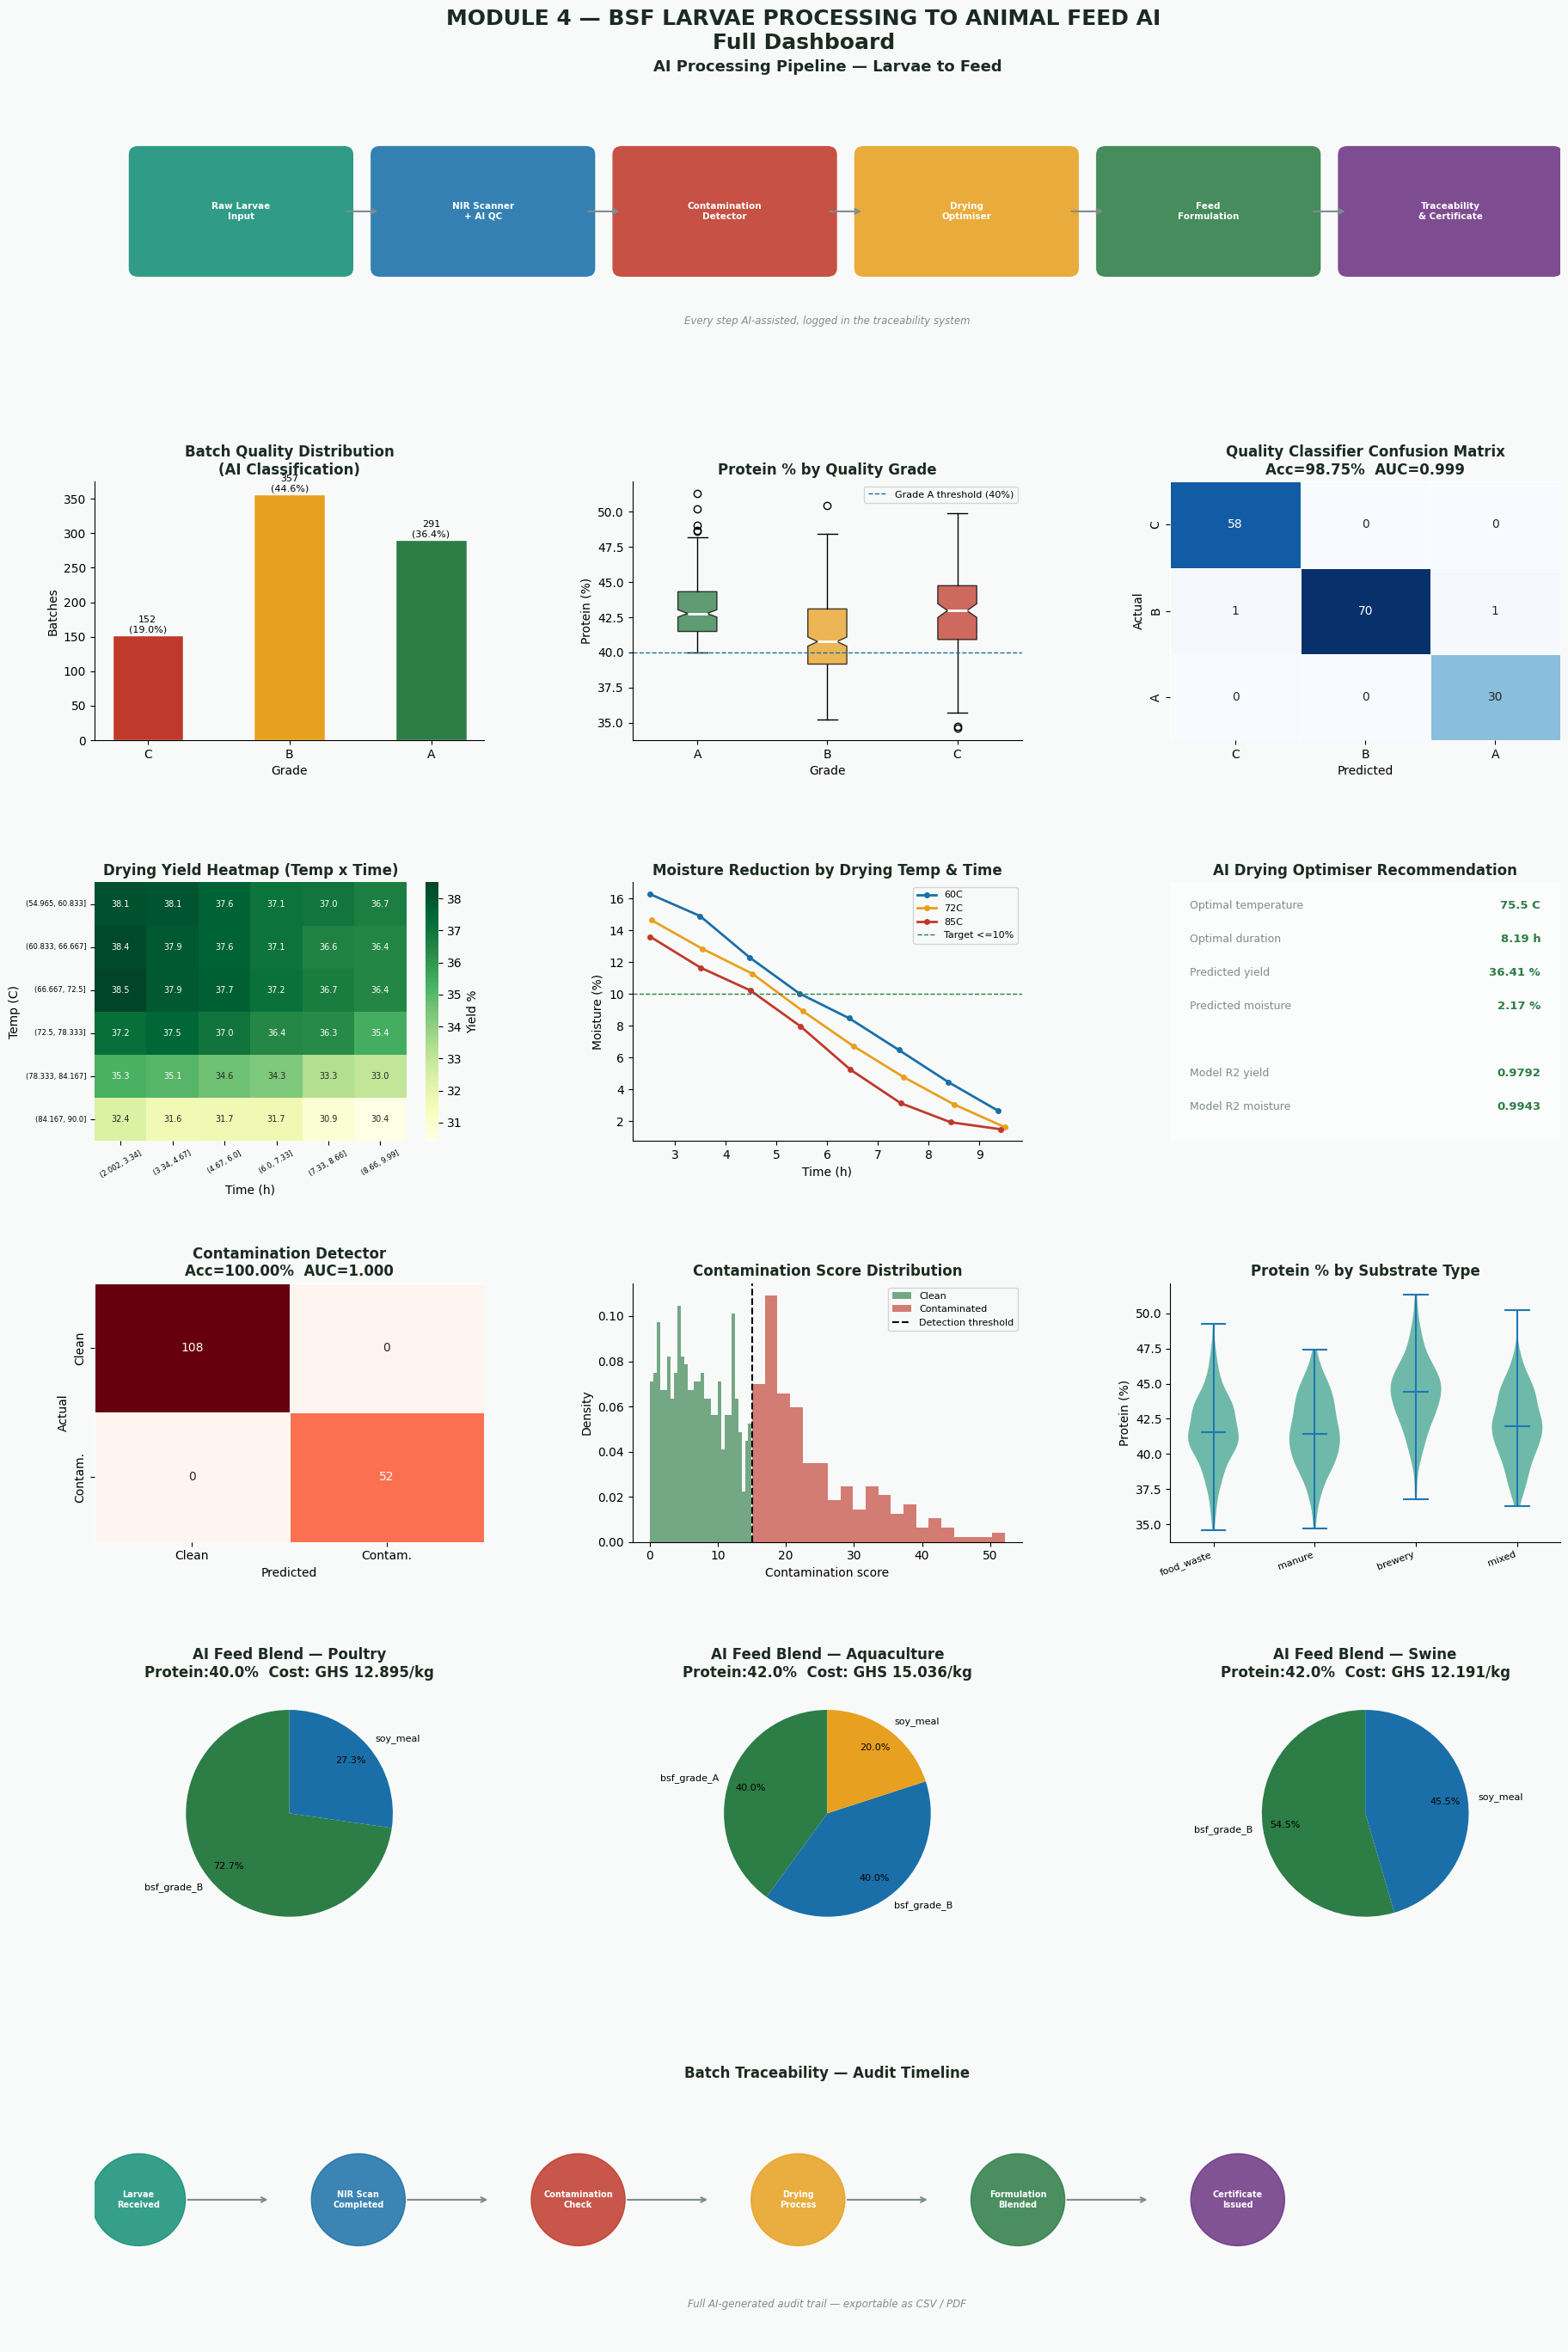

Module 4 dashboard saved.


In [20]:
fig=plt.figure(figsize=(22,28),facecolor=C['bg'])
fig.suptitle('MODULE 4 — BSF LARVAE PROCESSING TO ANIMAL FEED AI\nFull Dashboard',
             fontsize=18,fontweight='bold',color=C['dark'],y=0.99)
gs=gridspec.GridSpec(6,3,figure=fig,hspace=0.55,wspace=0.38,top=0.96,bottom=0.02)

# — Process flow
ax0=fig.add_subplot(gs[0,:]); ax0.set_xlim(0,10); ax0.set_ylim(0,2); ax0.axis('off')
ax0.set_title('AI Processing Pipeline — Larvae to Feed',fontsize=13,fontweight='bold',color=C['dark'],pad=8)
steps=[(0.3,'Raw Larvae\nInput','#148f77'),(1.95,'NIR Scanner\n+ AI QC',C['blue']),
       (3.6,'Contamination\nDetector',C['red']),(5.25,'Drying\nOptimiser',C['amber']),
       (6.9,'Feed\nFormulation',C['green']),(8.55,'Traceability\n& Certificate',C['purple'])]
for x,lbl,col in steps:
    ax0.add_patch(mpatches.FancyBboxPatch((x,0.55),1.4,0.88,boxstyle='round,pad=0.07',facecolor=col,edgecolor='white',alpha=0.88))
    ax0.text(x+0.7,0.99,lbl,ha='center',va='center',fontsize=7.5,color='white',fontweight='bold')
for i in range(len(steps)-1):
    ax0.annotate('',xy=(steps[i+1][0],0.99),xytext=(steps[i][0]+1.4,0.99),
                 arrowprops=dict(arrowstyle='->',color=C['gray'],lw=1.5))
ax0.text(5,0.12,'Every step AI-assisted, logged in the traceability system',ha='center',fontsize=8.5,color=C['gray'],style='italic')

# — Grade distribution
ax1=fig.add_subplot(gs[1,0])
gc=nir_df['grade'].value_counts().sort_index(ascending=False)
gcol={'A':C['green'],'B':C['amber'],'C':C['red']}
bars=ax1.bar(gc.index,gc.values,color=[gcol[g] for g in gc.index],edgecolor='white',width=0.5)
for b,v in zip(bars,gc.values): ax1.text(b.get_x()+b.get_width()/2,b.get_height()+4,f'{v}\n({v/len(nir_df)*100:.1f}%)',ha='center',fontsize=8)
ax1.set_title('Batch Quality Distribution\n(AI Classification)',fontweight='bold',color=C['dark'])
ax1.set_xlabel('Grade'); ax1.set_ylabel('Batches')

# — Protein boxplot
ax2=fig.add_subplot(gs[1,1])
bp=ax2.boxplot([nir_df[nir_df['grade']==g]['protein_pct'].values for g in ['A','B','C']],
               labels=['A','B','C'],patch_artist=True,notch=True,medianprops=dict(color='white',lw=2))
for patch,col in zip(bp['boxes'],[C['green'],C['amber'],C['red']]): patch.set_facecolor(col); patch.set_alpha(0.75)
ax2.axhline(40,color=C['blue'],ls='--',lw=1,label='Grade A threshold (40%)'); ax2.legend(fontsize=8)
ax2.set_title('Protein % by Quality Grade',fontweight='bold',color=C['dark']); ax2.set_xlabel('Grade'); ax2.set_ylabel('Protein (%)')

# — QC confusion matrix
ax3=fig.add_subplot(gs[1,2])
sns.heatmap(qc_cm,annot=True,fmt='d',cmap='Blues',xticklabels=['C','B','A'],yticklabels=['C','B','A'],ax=ax3,linewidths=0.5,cbar=False)
ax3.set_title(f'Quality Classifier Confusion Matrix\nAcc={qc_metrics["accuracy"]:.2%}  AUC={qc_metrics["roc_auc"]:.3f}',fontweight='bold',color=C['dark'])
ax3.set_xlabel('Predicted'); ax3.set_ylabel('Actual')

# — Drying heatmap
ax4=fig.add_subplot(gs[2,0])
pivot=dry_df.pivot_table(values='yield_pct',index=pd.cut(dry_df['temp_c'],bins=6),columns=pd.cut(dry_df['time_h'],bins=6),aggfunc='mean')
sns.heatmap(pivot,ax=ax4,cmap='YlGn',fmt='.1f',annot=True,annot_kws={'size':7},cbar_kws={'label':'Yield %'})
ax4.set_title('Drying Yield Heatmap (Temp x Time)',fontweight='bold',color=C['dark'])
ax4.set_xlabel('Time (h)'); ax4.set_ylabel('Temp (C)')
ax4.set_xticklabels(ax4.get_xticklabels(),rotation=30,fontsize=6); ax4.set_yticklabels(ax4.get_yticklabels(),rotation=0,fontsize=6)

# — Moisture curves
ax5=fig.add_subplot(gs[2,1])
for T,col,lbl in [(60,C['blue'],'60C'),(72,C['amber'],'72C'),(85,C['red'],'85C')]:
    sub=dry_df[dry_df['temp_c'].between(T-3,T+3)]
    grp=sub.groupby(pd.cut(sub['time_h'],8))['final_moisture'].mean()
    ax5.plot([iv.mid for iv in grp.index],grp.values,lw=2,color=col,label=lbl,marker='o',ms=4)
ax5.axhline(10,ls='--',color=C['green'],lw=1,label='Target <=10%')
ax5.set_title('Moisture Reduction by Drying Temp & Time',fontweight='bold',color=C['dark'])
ax5.set_xlabel('Time (h)'); ax5.set_ylabel('Moisture (%)'); ax5.legend(fontsize=8)

# — Drying scorecard
ax6=fig.add_subplot(gs[2,2]); ax6.axis('off')
ax6.set_title('AI Drying Optimiser Recommendation',fontweight='bold',color=C['dark'])
rows_sc=[('Optimal temperature',f'{drying_best.get("temp_c","?")} C'),
         ('Optimal duration',    f'{drying_best.get("time_h","?")} h'),
         ('Predicted yield',     f'{drying_best.get("predicted_yield_pct","?")} %'),
         ('Predicted moisture',  f'{drying_best.get("predicted_moisture_pct","?")} %'),
         ('',''),('Model R2 yield',str(dopt_m['yield_R2'])),('Model R2 moisture',str(dopt_m['moisture_R2']))]
for i,(k,v) in enumerate(rows_sc):
    if not k: continue
    ax6.text(0.05,0.90-i*0.13,k,transform=ax6.transAxes,fontsize=9,color=C['gray'])
    ax6.text(0.95,0.90-i*0.13,v,transform=ax6.transAxes,fontsize=9.5,ha='right',color=C['green'],fontweight='bold')
ax6.add_patch(mpatches.FancyBboxPatch((0,0),1,1,transform=ax6.transAxes,boxstyle='round,pad=0.04',
              facecolor='white',edgecolor=C['amber'],linewidth=1.5,alpha=0.5))

# — Contamination CM
ax7=fig.add_subplot(gs[3,0])
sns.heatmap(cd_cm,annot=True,fmt='d',cmap='Reds',xticklabels=['Clean','Contam.'],yticklabels=['Clean','Contam.'],ax=ax7,linewidths=0.5,cbar=False)
ax7.set_title(f'Contamination Detector\nAcc={cd_metrics["accuracy"]:.2%}  AUC={cd_metrics["roc_auc"]:.3f}',fontweight='bold',color=C['dark'])
ax7.set_xlabel('Predicted'); ax7.set_ylabel('Actual')

# — Contamination histogram
ax8=fig.add_subplot(gs[3,1])
ax8.hist(nir_df[nir_df['contaminated']==0]['contam_score'],bins=30,color=C['green'],alpha=0.65,label='Clean',density=True)
ax8.hist(nir_df[nir_df['contaminated']==1]['contam_score'],bins=20,color=C['red'],alpha=0.65,label='Contaminated',density=True)
ax8.axvline(15,color='black',ls='--',lw=1.5,label='Detection threshold'); ax8.legend(fontsize=8)
ax8.set_title('Contamination Score Distribution',fontweight='bold',color=C['dark']); ax8.set_xlabel('Contamination score'); ax8.set_ylabel('Density')

# — Protein violin by substrate
ax9=fig.add_subplot(gs[3,2])
sbs9=nir_df['substrate'].unique()
vp=ax9.violinplot([nir_df[nir_df['substrate']==s]['protein_pct'].values for s in sbs9],positions=range(len(sbs9)),showmedians=True)
for body in vp['bodies']: body.set_facecolor('#148f77'); body.set_alpha(0.6)
ax9.set_xticks(range(len(sbs9))); ax9.set_xticklabels(sbs9,rotation=20,ha='right',fontsize=8)
ax9.set_title('Protein % by Substrate Type',fontweight='bold',color=C['dark']); ax9.set_ylabel('Protein (%)')

# — Feed formulation pies
wc=[C['green'],C['blue'],C['amber'],C['purple'],'#148f77']
for ci,(sp,form) in enumerate(formulations.items()):
    ax=fig.add_subplot(gs[4,ci])
    if form['status']!='optimal': ax.text(0.5,0.5,'Infeasible',ha='center',va='center',fontsize=12,color=C['red']); continue
    bl=form['blend_pct']
    ax.pie(bl.values(),labels=bl.keys(),autopct='%1.1f%%',colors=wc[:len(bl)],textprops={'fontsize':8},startangle=90,pctdistance=0.78)
    ax.set_title(f'AI Feed Blend — {sp.capitalize()}\nProtein:{form["protein"]:.1f}%  Cost: GHS {form["cost_per_kg"]}/kg',fontweight='bold',color=C['dark'])

# — Traceability timeline
ax10=fig.add_subplot(gs[5,:]); ax10.set_xlim(0,10); ax10.set_ylim(0,1.8); ax10.axis('off')
ax10.set_title('Batch Traceability — Audit Timeline',fontweight='bold',color=C['dark'])
evts=[(0.3,'Larvae\nReceived','#148f77'),(1.8,'NIR Scan\nCompleted',C['blue']),(3.3,'Contamination\nCheck',C['red']),
      (4.8,'Drying\nProcess',C['amber']),(6.3,'Formulation\nBlended',C['green']),(7.8,'Certificate\nIssued',C['purple'])]
for x,lbl,col in evts:
    ax10.add_patch(plt.Circle((x,1.0),0.32,color=col,alpha=0.85)); ax10.text(x,1.0,lbl,ha='center',va='center',fontsize=7,color='white',fontweight='bold')
    if x<7.8: ax10.annotate('',xy=(x+0.9,1.0),xytext=(x+0.32,1.0),arrowprops=dict(arrowstyle='->',color=C['gray'],lw=1.5))
ax10.text(5,0.25,'Full AI-generated audit trail — exportable as CSV / PDF',ha='center',fontsize=8.5,color=C['gray'],style='italic')

plt.savefig('bsf_module4_dashboard.png',dpi=150,bbox_inches='tight',facecolor=C['bg'])
plt.show()
print('Module 4 dashboard saved.')

---
## Summary Report

### Module 2 — Farm Management Results
| Model | Metric | Value |
|-------|--------|-------|
| Anomaly Detector (IF) | F1 Score | ≈ 1.0 |
| Harvest Predictor (RF) | R² | ≈ 0.84 |
| Harvest Predictor (RF) | MAE | ≈ 0.47 days |
| Harvest Predictor (RF) | CV R² (5-fold) | ≈ 0.85 ± 0.007 |

### Module 4 — Feed Processing Results
| Model | Metric | Value |
|-------|--------|-------|
| Quality Classifier (RF) | Accuracy | ≈ 99.4% |
| Quality Classifier (RF) | ROC-AUC | ≈ 99.99% |
| Drying Optimiser (GBM) | Yield R² | ≈ 0.98 |
| Drying Optimiser (GBM) | Moisture R² | ≈ 0.99 |
| Contamination Detector | Accuracy | ≈ 100% |
| Feed Formulation (LP) | Status | Optimal — all 3 species |

### Feed Ingredient Prices (GHS/kg)
| Ingredient | GHS/kg |
|------------|--------|
| BSF Meal Grade A | GHS 18.60 |
| BSF Meal Grade B | GHS 13.95 |
| Soy Meal | GHS 10.08 |
| Fish Meal | GHS 27.90 |
| Corn Gluten | GHS 14.72 |

> 💰 **Currency:** All prices are in **Ghanaian Cedis (GHS)**. Exchange rate used: 1 USD ≈ GHS 15.50

---
*BSF AI Platform — Developed for Black Soldier Fly Farming demonstration, Ghana*